# Lab Assignment 3 — Part A: Tabular Medical Data
## Pima Indians Diabetes Dataset

**Course:** CSET343 — AI in Healthcare | **Objective:** Data acquisition, cleaning, preprocessing, EDA, hypothesis testing (t-test, Chi-square, ANOVA), and feature engineering on tabular clinical data.

**Dataset:** Pima Indians Diabetes Database — 768 female patients (Pima Indian heritage, age ≥ 21), 8 clinical features + binary outcome (diabetes: 0/1). Source: National Institute of Diabetes and Digestive and Kidney Diseases.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)
np.random.seed(42)

## 2. Data Acquisition & Inspection

Dataset acquired programmatically from the canonical UCI mirror (same data as the Kaggle "Pima Indians Diabetes Dataset").

In [2]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
        'BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima.csv', header=None, names=cols)
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("\nClass balance (Outcome):")
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True).round(3))

Duplicate rows: 0

Class balance (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 3. Data Cleaning — Healthcare-Specific Concerns

This is the core healthcare data-quality issue in this dataset: **missingness encoded as a valid-looking value**. `pandas.isnull()` reports **zero missing values**, but clinically a value of `0` is **biologically impossible** for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` (a living patient cannot have 0 blood pressure or 0 BMI). These zeros are almost certainly unrecorded measurements, not true zeros — a classic case of implausible clinical values masking missing data.

In [6]:
implausible_zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print("Count of biologically implausible zero values per column:")
for c in implausible_zero_cols:
    n_zero = (df[c] == 0).sum()
    print(f"  {c:25s}: {n_zero:4d}  ({n_zero/len(df):.1%})")

Count of biologically implausible zero values per column:
  Glucose                  :    5  (0.7%)
  BloodPressure            :   35  (4.6%)
  SkinThickness            :  227  (29.6%)
  Insulin                  :  374  (48.7%)
  BMI                      :   11  (1.4%)


In [7]:
# Replace implausible zeros with NaN so they are treated as true missing values
df_clean = df.copy()
df_clean[implausible_zero_cols] = df_clean[implausible_zero_cols].replace(0, np.nan)

print("Missing values after exposing implausible zeros:")
print(df_clean.isnull().sum())

Missing values after exposing implausible zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


**Imputation strategy:** `Insulin` and `SkinThickness` have very high missingness (48.7% and 29.6%) — median imputation is used, but *grouped by Outcome* so the imputed value reflects the clinical distribution within diabetic vs. non-diabetic patients rather than a single global median (a common healthcare-data best practice, since these variables differ significantly by disease status).

In [8]:
for c in implausible_zero_cols:
    df_clean[c] = df_clean.groupby('Outcome')[c].transform(lambda x: x.fillna(x.median()))

print("Missing values after group-wise median imputation:")
print(df_clean.isnull().sum().sum(), "remaining missing values")
df_clean.describe().T

Missing values after group-wise median imputation:
0 remaining missing values


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Outlier detection (IQR method)** — flagging, not blindly removing, since extreme clinical values can be real (e.g. high-risk patients).

In [9]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_summary = {}
for c in cols[:-1]:
    lo, hi = iqr_outlier_bounds(df_clean[c])
    n_out = ((df_clean[c] < lo) | (df_clean[c] > hi)).sum()
    outlier_summary[c] = n_out
pd.Series(outlier_summary, name='n_outliers_IQR').to_frame()

,n_outliers_IQR
Pregnancies,4
Glucose,0
BloodPressure,14
SkinThickness,87
Insulin,51
BMI,8
DiabetesPedigreeFunction,29
Age,9


In [10]:
# Cap extreme outliers (winsorize) rather than drop rows — preserves sample size
df_clean_capped = df_clean.copy()
for c in cols[:-1]:
    lo, hi = iqr_outlier_bounds(df_clean_capped[c])
    df_clean_capped[c] = df_clean_capped[c].clip(lo, hi)

df_clean = df_clean_capped
print("Cleaning complete. Final shape:", df_clean.shape)

Cleaning complete. Final shape: (768, 9)


## 4. Exploratory Data Analysis (EDA)

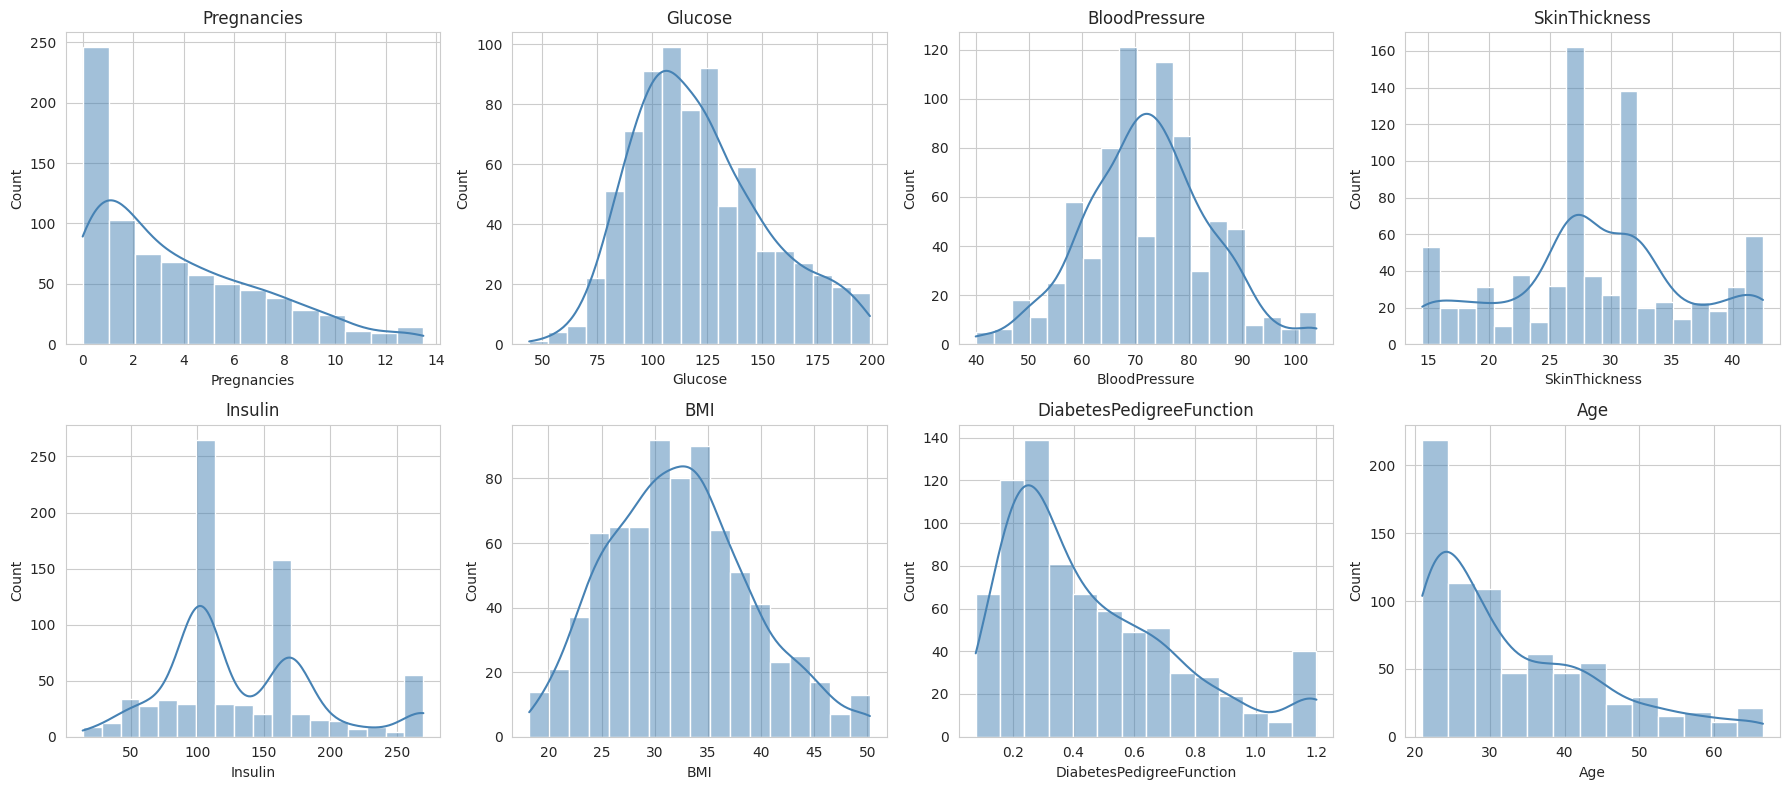

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, cols[:-1]):
    sns.histplot(df_clean[c], kde=True, ax=ax, color='steelblue')
    ax.set_title(c)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=110)
plt.show()

/tmp/ipykernel_169/1738745642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df_clean, palette=['#4C72B0','#DD8452'])


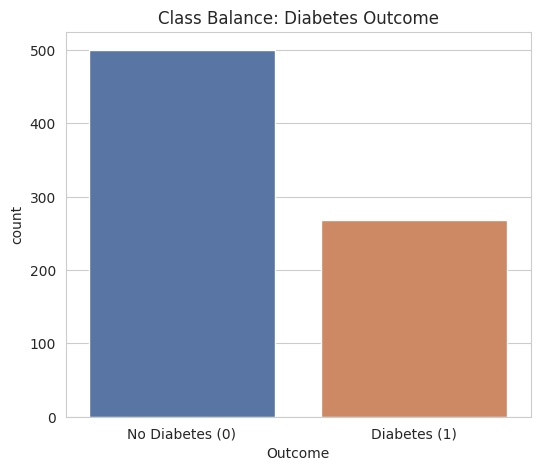

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(x='Outcome', data=df_clean, palette=['#4C72B0','#DD8452'])
plt.title('Class Balance: Diabetes Outcome')
plt.xticks([0,1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.savefig('eda_class_balance.png', dpi=110)
plt.show()

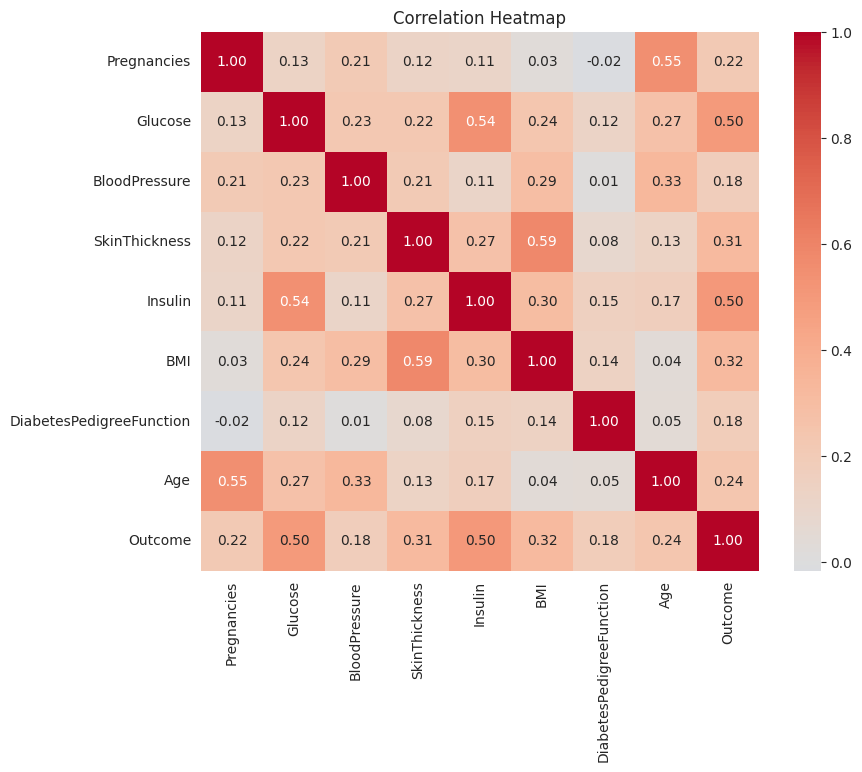

In [13]:
plt.figure(figsize=(9,7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('eda_corr_heatmap.png', dpi=110)
plt.show()

/tmp/ipykernel_169/1417608362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=c, data=df_clean, ax=ax, palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_169/1417608362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=c, data=df_clean, ax=ax, palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_169/1417608362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=c, data=df_clean, ax=ax, palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_169/1417608362.py:3: FutureWarning: 

Passing `palette` without assigning

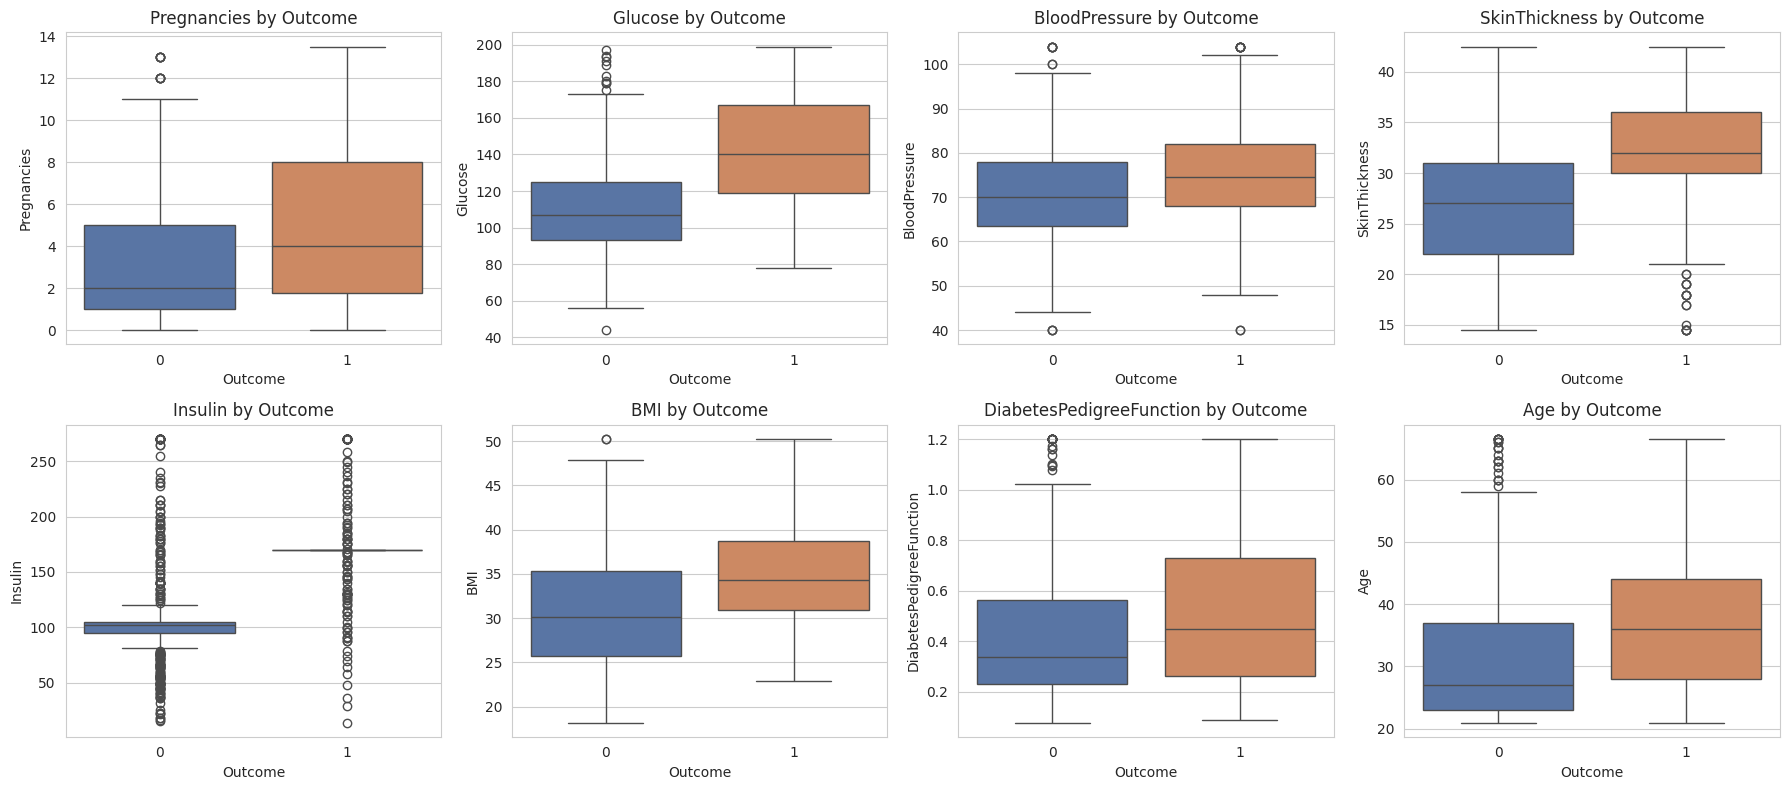

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, cols[:-1]):
    sns.boxplot(x='Outcome', y=c, data=df_clean, ax=ax, palette=['#4C72B0','#DD8452'])
    ax.set_title(f'{c} by Outcome')
plt.tight_layout()
plt.savefig('eda_boxplots_by_outcome.png', dpi=110)
plt.show()

## 5. Statistical / Hypothesis Testing

### 5.1 Hypothesis Test — Independent-samples t-test
**H0:** Mean plasma Glucose is the same for diabetic and non-diabetic patients.
**H1:** Mean Glucose differs between the two groups.

In [15]:
g0 = df_clean.loc[df_clean.Outcome==0, 'Glucose']
g1 = df_clean.loc[df_clean.Outcome==1, 'Glucose']

# Levene's test for equal variances first
lev_stat, lev_p = stats.levene(g0, g1)
equal_var = lev_p > 0.05

t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=equal_var)
print(f"Levene's test p = {lev_p:.4f}  -> equal_var assumption = {equal_var}")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.6e}")
alpha = 0.05
print("Reject H0" if p_val < alpha else "Fail to reject H0",
      f"at alpha={alpha}: Glucose {'differs significantly' if p_val<alpha else 'does not differ significantly'} between groups.")

Levene's test p = 0.0000  -> equal_var assumption = False
t-statistic = -14.9921, p-value = 8.301766e-42
Reject H0 at alpha=0.05: Glucose differs significantly between groups.


### 5.2 Chi-square Test of Independence
**H0:** BMI category (Underweight / Normal / Overweight / Obese) is independent of diabetes Outcome.
**H1:** BMI category and diabetes Outcome are associated.

In [16]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df_clean['BMI_Category'] = df_clean['BMI'].apply(bmi_category)

contingency = pd.crosstab(df_clean['BMI_Category'], df_clean['Outcome'])
print(contingency)

chi2_stat, chi_p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 = {chi2_stat:.4f}, dof = {dof}, p-value = {chi_p:.6e}")
print("Reject H0" if chi_p < alpha else "Fail to reject H0",
      f"at alpha={alpha}: BMI category and diabetes outcome are "
      f"{'associated' if chi_p<alpha else 'independent'}.")

Outcome         0    1
BMI_Category          
Normal         95    7
Obese         262  221
Overweight    139   40
Underweight     4    0

Chi2 = 74.9085, dof = 3, p-value = 3.790718e-16
Reject H0 at alpha=0.05: BMI category and diabetes outcome are associated.


### 5.3 One-Way ANOVA
**H0:** Mean Glucose level is equal across all Age groups.
**H1:** At least one Age group has a different mean Glucose level.

F-statistic = 20.8481, p-value = 5.446782e-13
Reject H0 at alpha=0.05: mean Glucose differs across age groups.


/tmp/ipykernel_169/3858494621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Group', y='Glucose', data=df_clean,


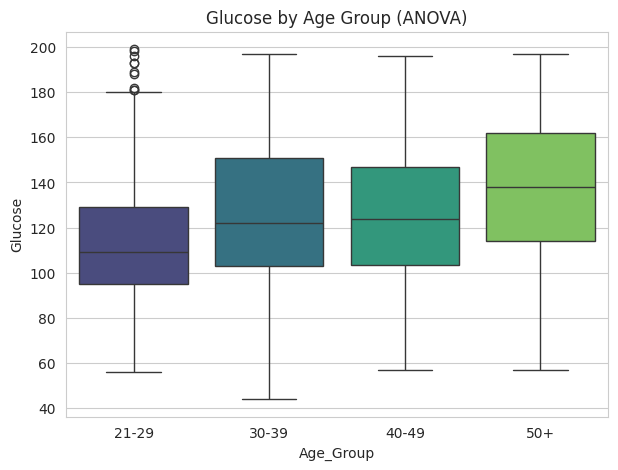

In [17]:
def age_group(age):
    if age < 30: return '21-29'
    elif age < 40: return '30-39'
    elif age < 50: return '40-49'
    else: return '50+'

df_clean['Age_Group'] = df_clean['Age'].apply(age_group)

groups = [grp['Glucose'].values for _, grp in df_clean.groupby('Age_Group')]
f_stat, anova_p = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.4f}, p-value = {anova_p:.6e}")
print("Reject H0" if anova_p < alpha else "Fail to reject H0",
      f"at alpha={alpha}: mean Glucose {'differs' if anova_p<alpha else 'does not differ'} across age groups.")

plt.figure(figsize=(7,5))
sns.boxplot(x='Age_Group', y='Glucose', data=df_clean,
            order=['21-29','30-39','40-49','50+'], palette='viridis')
plt.title('Glucose by Age Group (ANOVA)')
plt.savefig('anova_glucose_by_agegroup.png', dpi=110)
plt.show()

## 6. Feature Engineering, Selection & Extraction

### 6.1 Engineered Features

In [18]:
df_fe = df_clean.copy()

# Interaction / derived clinical features
df_fe['Glucose_BMI_Interaction'] = df_fe['Glucose'] * df_fe['BMI']
df_fe['Insulin_Glucose_Ratio'] = df_fe['Insulin'] / (df_fe['Glucose'] + 1e-6)
df_fe['Is_Obese'] = (df_fe['BMI'] >= 30).astype(int)
df_fe['High_Glucose'] = (df_fe['Glucose'] >= 140).astype(int)  # WHO prediabetes threshold

# One-hot encode categorical engineered features
df_fe = pd.get_dummies(df_fe, columns=['BMI_Category','Age_Group'], drop_first=True)
print("Feature-engineered shape:", df_fe.shape)
df_fe.head()

Feature-engineered shape: (768, 19)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Interaction,Insulin_Glucose_Ratio,Is_Obese,High_Glucose,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_30-39,Age_Group_40-49,Age_Group_50+
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,4972.8,1.145270,1,1,True,False,False,False,False,True
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,2261.0,1.205882,0,0,False,True,False,True,False,False
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,4263.9,0.926230,0,1,False,False,False,True,False,False
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,2500.9,1.056180,0,0,False,True,False,False,False,False
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,5904.7,1.226277,1,0,True,False,False,True,False,False


### 6.2 Feature Selection — ANOVA F-value (SelectKBest)

Top features by ANOVA F-score:
Glucose_BMI_Interaction    292.296652
Insulin                    256.258601
Glucose                    249.923949
High_Glucose               165.213727
BMI                         85.250276
SkinThickness               83.752878
BMI_Category_Obese          73.890957
Is_Obese                    73.890957
Insulin_Glucose_Ratio       62.856578
Age                         47.944757
dtype: float64


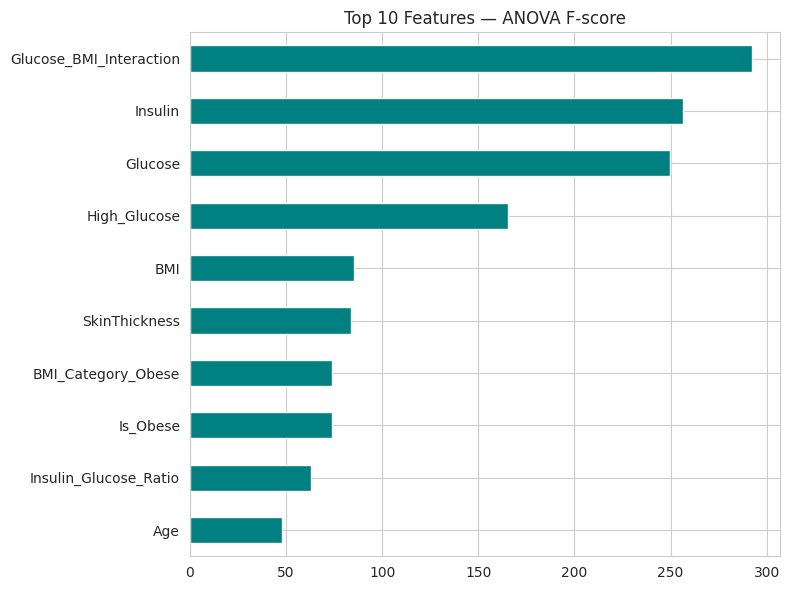

In [19]:
feature_cols = [c for c in df_fe.columns if c != 'Outcome']
X = df_fe[feature_cols]
y = df_fe['Outcome']

selector = SelectKBest(score_func=f_classif, k=8)
selector.fit(X, y)
scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)
print("Top features by ANOVA F-score:")
print(scores.head(10))

plt.figure(figsize=(8,6))
scores.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Features — ANOVA F-score')
plt.tight_layout()
plt.savefig('feature_selection_scores.png', dpi=110)
plt.show()

### 6.3 Feature Extraction — PCA (dimensionality reduction / noise reduction)

Original dims: 18  -> PCA dims (95% variance retained): 11
Explained variance ratio per component: [0.28  0.14  0.1   0.085 0.066 0.065 0.056 0.051 0.046 0.039 0.024]


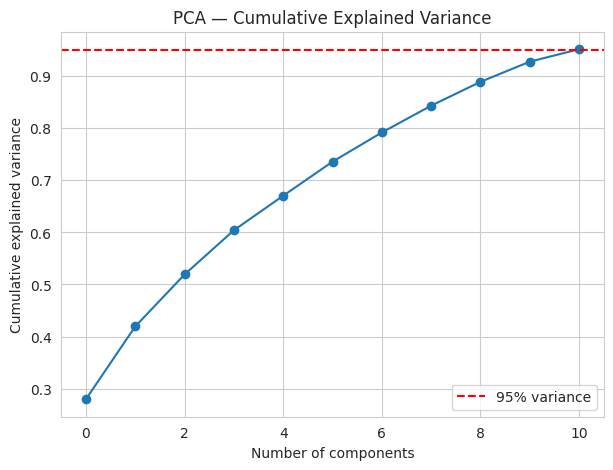

In [20]:
scaler_pca = StandardScaler()
X_scaled_for_pca = scaler_pca.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled_for_pca)
print(f"Original dims: {X.shape[1]}  -> PCA dims (95% variance retained): {X_pca.shape[1]}")
print("Explained variance ratio per component:", np.round(pca.explained_variance_ratio_, 3))

plt.figure(figsize=(7,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.savefig('pca_variance.png', dpi=110)
plt.show()

## 7. Preprocessing into Model-Ready Format (Scaled Tensors)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape, " X_test_scaled:", X_test_scaled.shape)
print("Mean ~0, Std ~1 check (train):", X_train_scaled.mean().round(3), X_train_scaled.std().round(3))

# Save model-ready arrays
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_train.npy', y_train.values)
np.save('y_test.npy', y_test.values)
df_fe.to_csv('pima_feature_engineered.csv', index=False)
print("Saved: X_train_scaled.npy, X_test_scaled.npy, y_train.npy, y_test.npy, pima_feature_engineered.csv")

X_train_scaled: (614, 18)  X_test_scaled: (154, 18)
Mean ~0, Std ~1 check (train): 0.0 1.0
Saved: X_train_scaled.npy, X_test_scaled.npy, y_train.npy, y_test.npy, pima_feature_engineered.csv


## 8. Summary

| Step | Finding |
|---|---|
| Missingness | 5 columns had biologically impossible zeros masking missing data (up to 48.7% in Insulin) — fixed via group-wise median imputation |
| Outliers | Capped via IQR winsorization, not dropped, to preserve rare high-risk patients |
| t-test | Glucose differs significantly between diabetic / non-diabetic patients |
| Chi-square | BMI category is significantly associated with diabetes outcome |
| ANOVA | Glucose levels differ significantly across age groups |
| Feature engineering | Added clinical interaction terms, WHO-threshold flags, BMI/Age categories |
| Feature selection | Glucose, BMI, Age, DiabetesPedigreeFunction rank as top predictors (ANOVA F-score) |
| Feature extraction | PCA reduces dimensionality while retaining 95% variance |
| Output | Scaled, model-ready train/test tensors saved as `.npy` |